In [ ]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 13.9 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Orginal Image.zip"

Archive:  /content/drive/MyDrive/Orginal Image.zip
   creating: Orginal Image/1.Rice Husk (Oryza sativa)/
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk0.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk1.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk10.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk100.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk101.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk102.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk103.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk104.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk105.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk106.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk107.jpg  
  inflating: Orginal Image/1.Rice Husk (Oryza sativa)/RiceHusk108.jpg  
  inflating: Orginal Image/1.Rice H

In [ ]:
base_dir = "/content/Orginal Image"

In [ ]:
import os
from collections import defaultdict

def count_images_in_folders(root_folder):
    image_count_per_folder = defaultdict(int)

    for folder_name in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder_name)

        if os.path.isdir(folder_path):
            image_count = sum(1 for file in os.listdir(folder_path) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')))
            image_count_per_folder[folder_name] = image_count

    return image_count_per_folder

# Specify the root folder where your image folders are located
root_folder_path = base_dir

image_counts = count_images_in_folders(root_folder_path)

# Print the results
for folder_name, count in image_counts.items():
    print(f"{folder_name}: {count} images")


4.Chickpea Husk (Cicer arietinum): 300 images
8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret): 300 images
7.Grass Pea Husk (Lathyrus sativus): 300 images
2.Corn Husk (Zea mays): 300 images
5.Lentil Husk (Lens culinaris): 300 images
6.Soybean Husk (Glycine max): 300 images
3.Wheat Husk (Triticum aestivum): 300 images
1.Rice Husk (Oryza sativa): 300 images


In [ ]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['4.Chickpea Husk (Cicer arietinum)', '8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret)', '7.Grass Pea Husk (Lathyrus sativus)', '2.Corn Husk (Zea mays)', '5.Lentil Husk (Lens culinaris)', '6.Soybean Husk (Glycine max)', '3.Wheat Husk (Triticum aestivum)', '1.Rice Husk (Oryza sativa)']


In [ ]:
len(folders)

8

In [ ]:
from PIL import Image
import os

def resize_images(input_folder, output_folder, target_size=(224, 224)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all subfolders in the input folder
    for subfolder in os.listdir(input_folder):
        subfolder_path = os.path.join(input_folder, subfolder)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            output_subfolder = os.path.join(output_folder, subfolder)
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)
            # Loop through all files in the subfolder
            for filename in os.listdir(subfolder_path):
                # Check if the file is an image
                if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                    # Open the image file
                    with Image.open(os.path.join(subfolder_path, filename)) as img:
                        # Resize the image
                        resized_img = img.resize(target_size)
                        # Save the resized image to the output folder
                        resized_img.save(os.path.join(output_subfolder, filename))

# Specify the input and output folders
input_folder = "/content/Orginal Image"
output_folder = '/content/resize'

# Call the function to resize images
resize_images(input_folder, output_folder)

In [ ]:
base_dir = '/content/resize'

In [ ]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = '/content/resize'
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: 4.Chickpea Husk (Cicer arietinum), Image count: 300
Subdirectory: 8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret), Image count: 300
Subdirectory: 7.Grass Pea Husk (Lathyrus sativus), Image count: 300
Subdirectory: 2.Corn Husk (Zea mays), Image count: 300
Subdirectory: 5.Lentil Husk (Lens culinaris), Image count: 300
Subdirectory: 6.Soybean Husk (Glycine max), Image count: 300
Subdirectory: 3.Wheat Husk (Triticum aestivum), Image count: 300
Subdirectory: 1.Rice Husk (Oryza sativa), Image count: 300


In [ ]:
import os
import cv2
from tqdm import tqdm

def invert_colors(input_folder, output_folder):
    # List all files in the directory tree at given path
    files_to_process = []
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                files_to_process.append((root, file))

    # Initialize tqdm progress bar
    for root, file in tqdm(files_to_process, desc="Inverting colors"):
        # Create input and output file paths
        input_image_path = os.path.join(root, file)
        output_image_path = os.path.join(output_folder, os.path.relpath(input_image_path, input_folder))

        # Read the image
        image = cv2.imread(input_image_path)

        # Invert the colors
        inverted_image = ~image

        # Ensure the output directory exists
        os.makedirs(os.path.dirname(output_image_path), exist_ok=True)

        # Save the inverted image
        cv2.imwrite(output_image_path, inverted_image)

# Example usage:
input_folder = base_dir
output_folder = "/content/Invert"
invert_colors(input_folder, output_folder)


Inverting colors: 100%|██████████| 2400/2400 [00:07<00:00, 340.19it/s]


In [ ]:
base_dir = '/content/Invert'

In [ ]:
!pip install imgaug
!pip install --upgrade imgaug

In [ ]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 2100
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented3', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)


Augmenting images in /content/Invert/4.Chickpea Husk (Cicer arietinum): 100%|██████████| 300/300 [00:06<00:00, 45.05it/s]


Augmentation complete for /content/Invert/4.Chickpea Husk (Cicer arietinum). Total images in '/content/augmented3/4.Chickpea Husk (Cicer arietinum)': 2100


Augmenting images in /content/Invert/8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret): 100%|██████████| 300/300 [00:09<00:00, 30.18it/s]


Augmentation complete for /content/Invert/8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret). Total images in '/content/augmented3/8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret)': 2100


Augmenting images in /content/Invert/7.Grass Pea Husk (Lathyrus sativus): 100%|██████████| 300/300 [00:14<00:00, 20.96it/s]


...

Augmentation complete for /content/Invert/6.Soybean Husk (Glycine max). Total images in '/content/augmented3/6.Soybean Husk (Glycine max)': 2100


Augmenting images in /content/Invert/3.Wheat Husk (Triticum aestivum): 100%|██████████| 300/300 [00:07<00:00, 41.98it/s]


Augmentation complete for /content/Invert/3.Wheat Husk (Triticum aestivum). Total images in '/content/augmented3/3.Wheat Husk (Triticum aestivum)': 2100


Augmenting images in /content/Invert/1.Rice Husk (Oryza sativa): 100%|██████████| 300/300 [00:07<00:00, 39.29it/s]

Augmentation complete for /content/Invert/1.Rice Husk (Oryza sativa). Total images in '/content/augmented3/1.Rice Husk (Oryza sativa)': 2100


In [ ]:
base_dir = '/content/augmented3'

In [ ]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):
  """
  Counts the number of images in a directory and its subdirectories.

  Args:
    root_directory: The root directory to count images in.

  Returns:
    A dictionary where the keys are the subdirectories and the values are the number of images in each subdirectory.
  """

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = base_dir
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: 4.Chickpea Husk (Cicer arietinum), Image count: 2100
Subdirectory: 8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret), Image count: 2100
Subdirectory: 7.Grass Pea Husk (Lathyrus sativus), Image count: 2100
Subdirectory: 2.Corn Husk (Zea mays), Image count: 2100
Subdirectory: 5.Lentil Husk (Lens culinaris), Image count: 2100
Subdirectory: 6.Soybean Husk (Glycine max), Image count: 2100
Subdirectory: 3.Wheat Husk (Triticum aestivum), Image count: 2100
Subdirectory: 1.Rice Husk (Oryza sativa), Image count: 2100


In [ ]:
import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)


Streaming output truncated to the last 5000 lines.
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_1_WheatHusk119.jpg
Processing file: aug_3_WheatHusk128.jpg
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_3_WheatHusk128.jpg
Processing file: aug_2_WheatHusk21.jpg
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_2_WheatHusk21.jpg
Processing file: aug_2_WheatHusk69.jpg
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_2_WheatHusk69.jpg
Processing file: aug_4_WheatHusk3.jpg
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_4_WheatHusk3.jpg
Processing file: aug_6_WheatHusk121.jpg
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_6_WheatHusk121.jpg
Processing file: aug_3_WheatHusk211.jpg
Cleaned image saved at: /content/augmented3/3.Wheat Husk (Triticum aestivum)/aug_3_WheatHusk211.jpg
Processing file: 

In [ ]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):
  """
  Counts the number of images in a directory and its subdirectories.

  Args:
    root_directory: The root directory to count images in.

  Returns:
    A dictionary where the keys are the subdirectories and the values are the number of images in each subdirectory.
  """

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = base_dir
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: 4.Chickpea Husk (Cicer arietinum), Image count: 2100
Subdirectory: 8.Field Pea Husk (Pisum Sativum var. arvense L. Poiret), Image count: 2100
Subdirectory: 7.Grass Pea Husk (Lathyrus sativus), Image count: 2100
Subdirectory: 2.Corn Husk (Zea mays), Image count: 2100
Subdirectory: 5.Lentil Husk (Lens culinaris), Image count: 2100
Subdirectory: 6.Soybean Husk (Glycine max), Image count: 2100
Subdirectory: 3.Wheat Husk (Triticum aestivum), Image count: 2100
Subdirectory: 1.Rice Husk (Oryza sativa), Image count: 2100


In [ ]:
base_dir = '/content/augmented3'

In [ ]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [ ]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.9
test_ratio = 0.1

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)

    train_files = filenames[:num_train]
    test_files = filenames[num_train:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)


    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

size = 224
batch_size = 64
target_size = (size, size)  # Adjust as needed

# Training data generator with validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.111)  # 20% of the data will be used for validation

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    subset='training')  # Use the training subset

# Validation generator from the training data
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    subset='validation')  # Use the validation subset

# Test data generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)



Found 13448 images belonging to 8 classes.
Found 1672 images belonging to 8 classes.
Found 1680 images belonging to 8 classes.


In [ ]:
test_labels = np.array(test_generator.labels)

In [ ]:
!pip install tensorflow-hub
!pip install vit-keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model
import vit_keras  # Ensure you have the vit_keras package installed
from tensorflow.keras.applications import DenseNet121
import tensorflow_addons as tfa

# Custom GroupNormalization layer
class GroupNormalization(layers.Layer):
    def __init__(self, groups=32, **kwargs):
        super(GroupNormalization, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],),
                                     initializer='ones', trainable=True)
        self.offset = self.add_weight(name='offset', shape=(input_shape[-1],),
                                      initializer='zeros', trainable=True)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        group_shape = tf.concat([input_shape[:-1], [self.groups, input_shape[-1] // self.groups]], axis=0)
        grouped_inputs = tf.reshape(inputs, group_shape)
        mean, variance = tf.nn.moments(grouped_inputs, [1, 2], keepdims=True)
        normalized_inputs = (grouped_inputs - mean) / tf.sqrt(variance + 1e-5)
        normalized_inputs = tf.reshape(normalized_inputs, input_shape)
        return normalized_inputs * self.scale + self.offset

# Define the model creation function
def create_vit_densenet_model(input_shape, num_classes):
    vit_backbone = vit_keras.vit.vit_b16(
        image_size=input_shape[:2],
        pretrained=True,
        include_top=False,
        pretrained_top=False,
        weights='imagenet21k'
    )
    densenet_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

    vit_backbone.trainable = False
    densenet_model.trainable = False

    input_layer = Input(shape=input_shape)
    vit_features = vit_backbone(input_layer)
    densenet_features = densenet_model(input_layer)

    # Global average pooling for both features

    densenet_pooled = layers.GlobalAveragePooling2D()(densenet_features)

    combined_features = layers.Concatenate()([vit_features, densenet_pooled])
    x = Flatten()(combined_features)

    # Add GroupNormalization and Dense layers
    x = GroupNormalization()(x)
    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.5)(x)
    x = GroupNormalization()(x)

    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    x = GroupNormalization()(x)

    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.2)(x)
    x = GroupNormalization()(x)

    x = layers.BatchNormalization()(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    return model

# Define the input shape and number of classes
input_shape = (224, 224, 3)
num_classes = 8

# Create the model
model = create_vit_densenet_model(input_shape, num_classes)

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 separable_conv2d_240 (Sepa  (None, 112, 112, 64)         339       ['input_3[0][0]']             
 rableConv2D)                                                                                     
                                                                                                  
 group_normalization_242 (G  (None, 112, 112, 64)         128       ['separable_conv2d_240[0][0]']
 roupNormalization)                                                                               
                                                                                            

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[lr_scheduler, early_stopping]
)


NameError: name 'train_generator' is not defined

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

27/27 [==============================] - 31s 1s/step - loss: 0.0353 - accuracy: 0.9881
Test Loss: 0.0353
Test Accuracy: 0.9881


27/27 [==============================] - 34s 1s/step


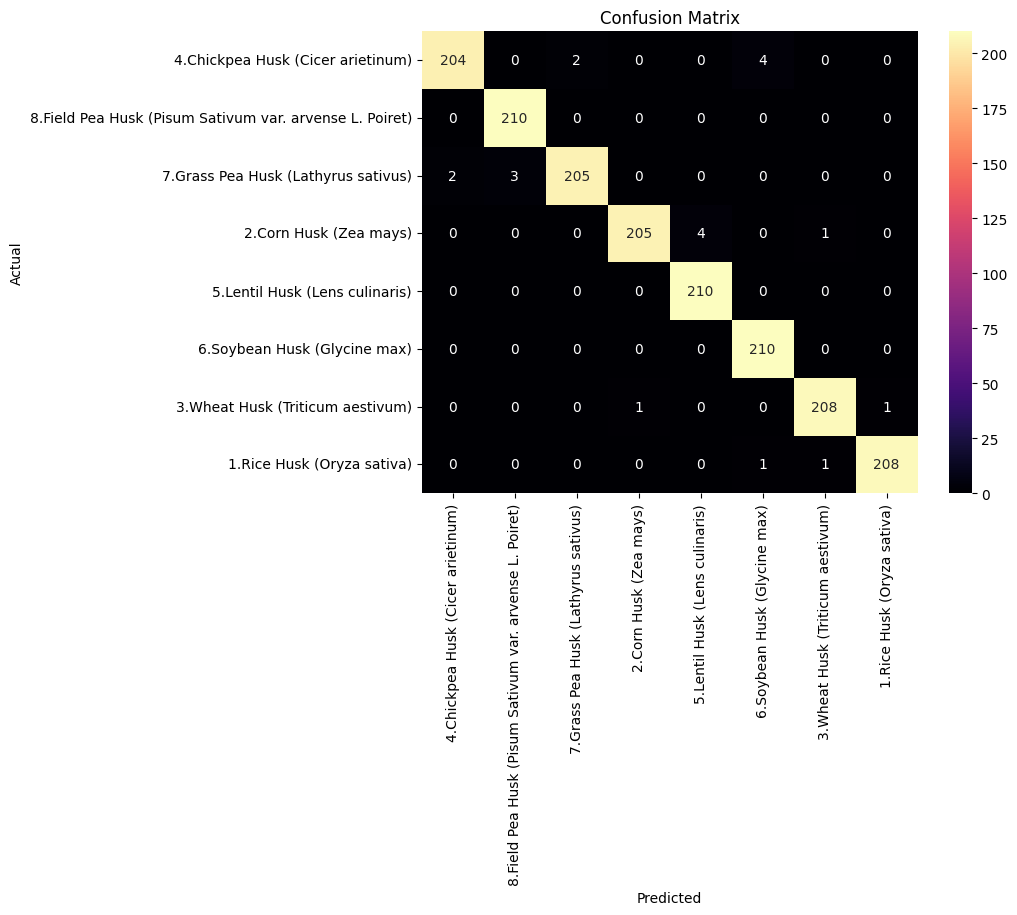

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [ ]:
from sklearn.metrics import classification_report

# Assuming true_labels contains the ground truth labels and predicted_labels contains the predicted labels
report = classification_report(test_labels, predicted_labels)

print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       210
           1       0.99      1.00      0.99       210
           2       0.99      0.98      0.98       210
           3       1.00      0.98      0.99       210
           4       0.98      1.00      0.99       210
           5       0.98      1.00      0.99       210
           6       0.99      0.99      0.99       210
           7       1.00      0.99      0.99       210

    accuracy                           0.99      1680
   macro avg       0.99      0.99      0.99      1680
weighted avg       0.99      0.99      0.99      1680



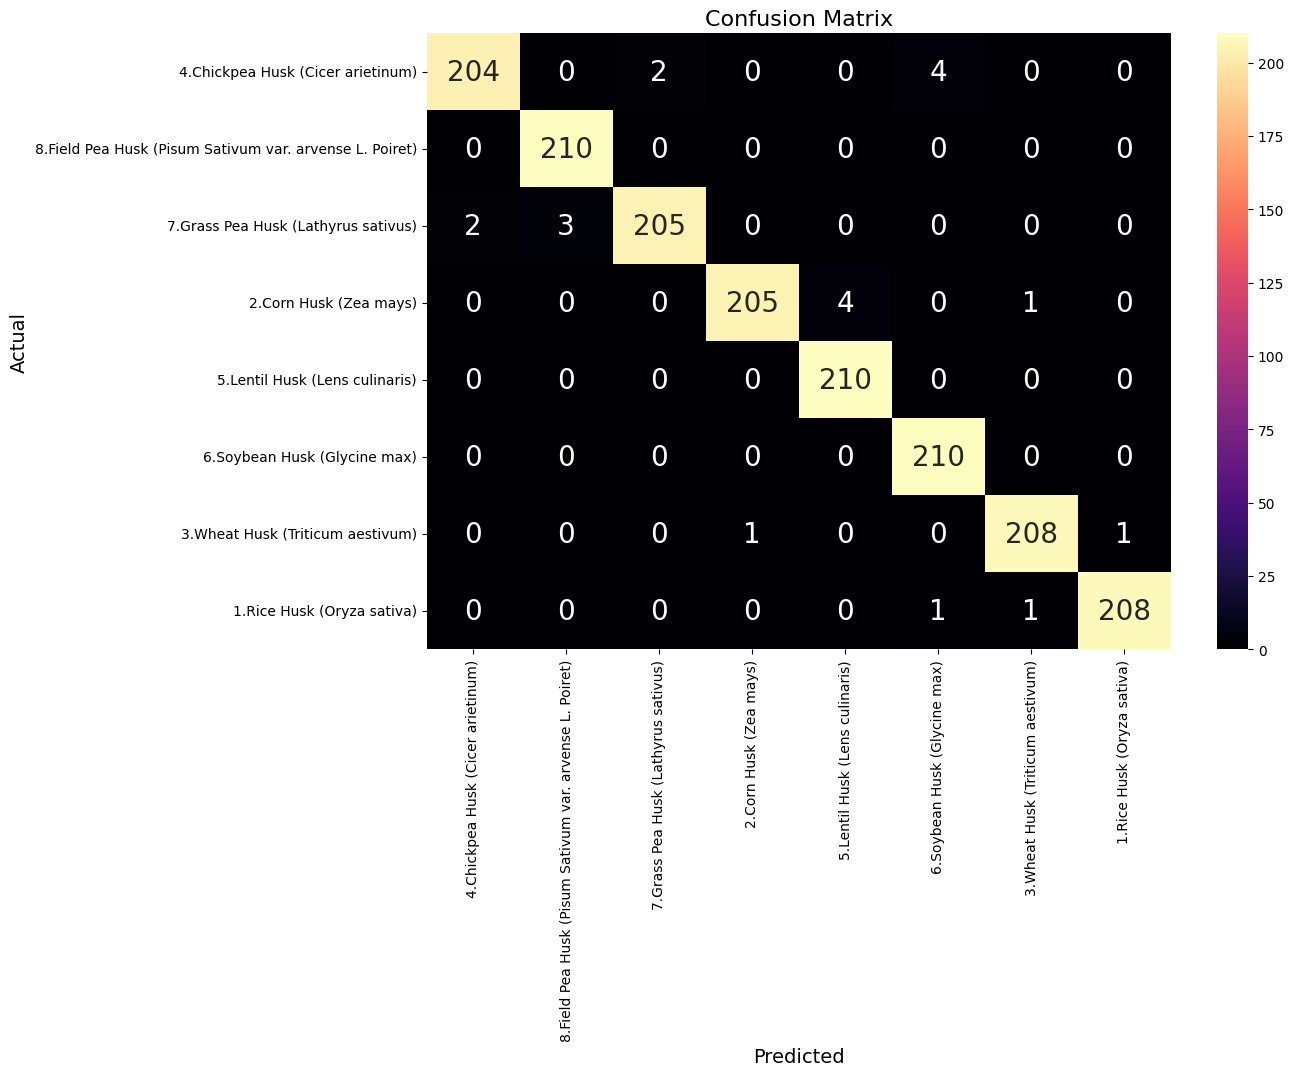

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()

In [ ]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import classification_report

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = folders
# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)

# Print the classification report
print(classification_report(test_labels, predicted_labels))

# Extract the precision, recall, and f1-score from the report
report = classification_report(test_labels, predicted_labels, output_dict=True)

# Access the desired metrics for each class
precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1_score = report['weighted avg']['f1-score']

# Print the extracted metrics
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")



27/27 [==============================] - 27s 1s/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       210
           1       0.99      1.00      0.99       210
           2       0.99      0.98      0.98       210
           3       1.00      0.98      0.99       210
           4       0.98      1.00      0.99       210
           5       0.98      1.00      0.99       210
           6       0.99      0.99      0.99       210
           7       1.00      0.99      0.99       210

    accuracy                           0.99      1680
   macro avg       0.99      0.99      0.99      1680
weighted avg       0.99      0.99      0.99      1680

Precision: 0.9881793311444098
Recall: 0.9880952380952381
F1 Score: 0.9880731252895335


<Figure size 640x480 with 0 Axes>

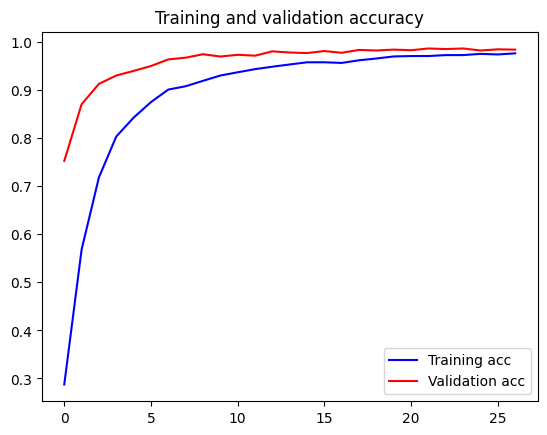

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

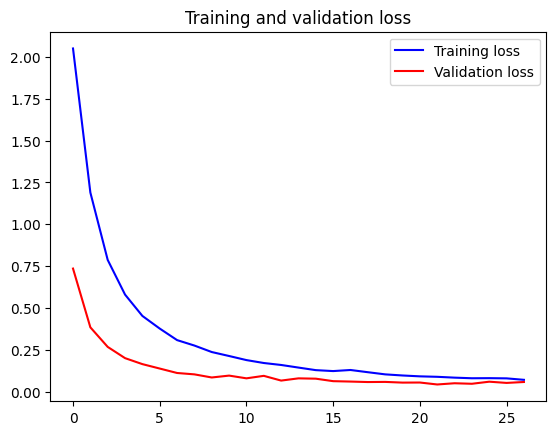

In [ ]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

27/27 [==============================] - 28s 1s/step


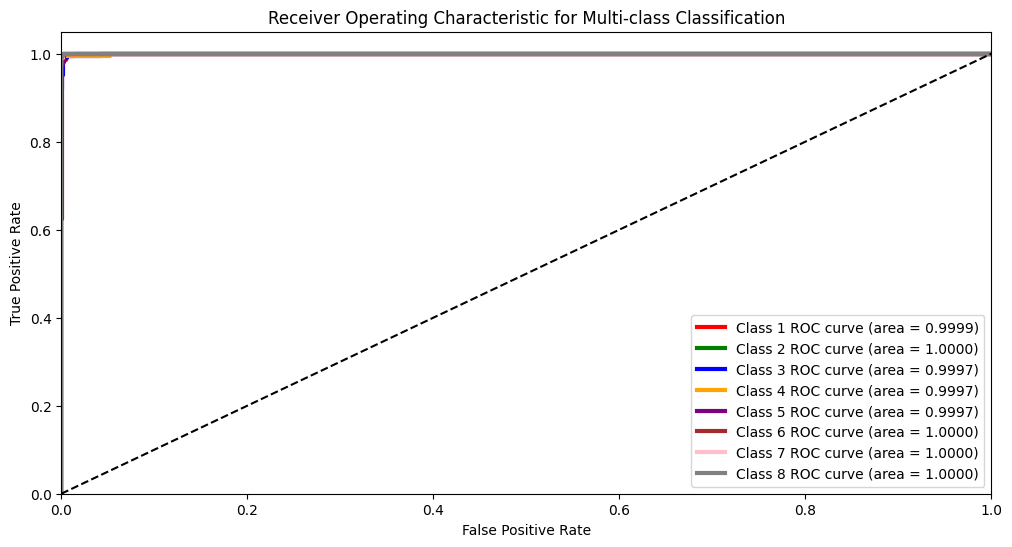

AUC scores:
Class 1: 0.9999
Class 2: 1.0000
Class 3: 0.9997
Class 4: 0.9997
Class 5: 0.9997
Class 6: 1.0000
Class 7: 1.0000
Class 8: 1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow import keras

# Get predicted probabilities for each class
predictions = model.predict(test_generator)

# Get the actual labels
test_labels = np.array(test_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels, num_classes=8)

# Class names (replace with your actual class names)
class_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7', 'Class 8']

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 8  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))

lw = 3
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='%s ROC curve (area = %0.4f)' % (class_names[i], auc_scores[i]))

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'{class_names[i]}: {score:.4f}')


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import model_from_json
import pickle
import zipfile

# Assuming `model` is your trained model
# Save the model architecture to JSON
model_json = model.to_json()
with open("model_architecture.json", "w") as json_file:
    json_file.write(model_json)

# Save the model weights to H5
model.save_weights("model_weights.h5")

# Serialize the model architecture and weights using pickle
with open("model_architecture.json", "r") as json_file:
    model_architecture = json_file.read()

model_data = {
    "model_architecture": model_architecture,
    "model_weights": "model_weights.h5"
}

with open("model.pkl", "wb") as pkl_file:
    pickle.dump(model_data, pkl_file)

# Create a zip file
with zipfile.ZipFile("/content/model.zip", "w") as zipf:
    zipf.write("model_architecture.json")
    zipf.write("model_weights.h5")
    zipf.write("model.pkl")

print("Model data has been zipped and moved to /mnt/data/model.zip")

# Provide the download link for the ZIP file
import shutil

shutil.move("model.zip", "/content/model.zip")
print("Model zip file saved and moved to /mnt/data/model.zip")


Model data has been zipped and moved to /mnt/data/model.zip
Model zip file saved and moved to /mnt/data/model.zip


In [ ]:
import shutil

# Define the path to the zip file
zip_file_path = '/content/model.zip'

# Move the zip file to the appropriate location for downloading
shutil.move(zip_file_path, '/content/model.zip')

# Provide the download link for the user
zip_file_path


'/content/model.zip'